In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

step 1: Load Dataset

In [2]:
df = pd.read_csv("data/diabetes.csv")

df.info() # show the summary of the dataset
df.head() # show the first 5 rows of the dataset

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


step 2: Detect Missing Value 

replace 0 -> NAN, check%

In [3]:
# Check for missing values
df.isnull().sum()
df.describe() # show the statistical summary of the dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
# Replace 0 values with NaN for specific columns: glucose, BloodPressure, SkinThickness, Insulin, and BMI
df['Glucose'] = df['Glucose'].replace(0, np.nan)
df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)
df['SkinThickness'] = df['SkinThickness'].replace(0, np.nan)
df['Insulin'] = df['Insulin'].replace(0, np.nan)
df['BMI'] = df['BMI'].replace(0, np.nan)

df.describe() # show the summary statistics of the dataset after replacing 0 with NaN

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.isnull().sum() / len(df) * 100 # show the percentage of missing values in each column

Pregnancies                  0.000000
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                      0.000000
dtype: float64

step 3: Imputation Step

In [6]:
# Drop rows with missing values in the columns: Glucose, BloodPressure, and BMI
df = df.dropna(subset=['Glucose', 'BloodPressure', 'BMI'])

# Fill missing values in the columns: Insulin and SkinThickness with the median value of each column
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].median())
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].median())

In [7]:
# before dropna df have 768 rows
# after dropna + fillna, what is the number of rows in df ?
print(len(df))

df.isnull().sum() # show the number of missing values in each column after handling missing values

724


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Step 4: EDA & Visualization

C:\Users\Asus\AppData\Local\Temp\ipykernel_26800\35806646.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([group0, group1], labels=['No Diabetes', 'Diabetes'])


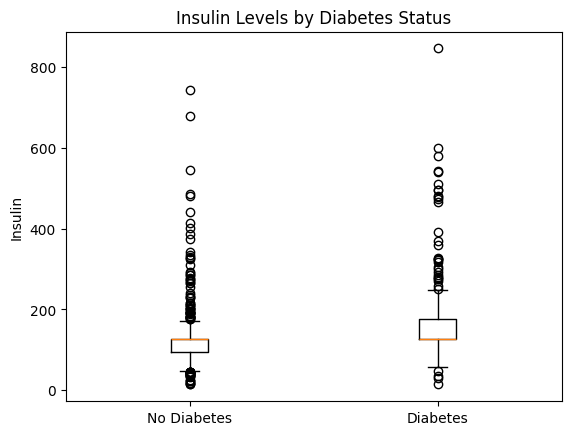

BMI        0.299375
Glucose    0.488384
Age        0.245741
Insulin    0.211736
Outcome    1.000000
Name: Outcome, dtype: float64

In [8]:
# seperate the data into two groups based on the Outcome column
group0 = df[df['Outcome'] == 0]['Insulin'].dropna()
group1 = df[df['Outcome'] == 1]['Insulin'].dropna()

plt.boxplot([group0, group1], labels=['No Diabetes', 'Diabetes'])
plt.ylabel('Insulin')
plt.title('Insulin Levels by Diabetes Status')
plt.show()
df[['BMI', 'Glucose', 'Age', 'Insulin', 'Outcome']].corr()['Outcome'] # show the correlation of the Outcome column

Step 5: Feature Engineering

scale features before modeling 

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x = df.drop(columns=['Outcome']) # drop the Outcome columns from the dataset
y = df['Outcome'] # set the Outcome column as the target variable

X_scaled = scaler.fit_transform(x) # 724 rows and 8 columns of scaled features
print(X_scaled.shape)

(724, 8)


step 6: Train/Test Split 

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,   # scaled features
    y,          # target 
    test_size=0.2, 
    random_state=42     # fix the random state for reproducibility
)

print(X_train.shape)
print(X_test.shape)

(579, 8)
(145, 8)


In [ ]:
from sklearn.linear_model import LogisticRegression

# create a Logistic Regression model
model = LogisticRegression(random_state=42)

# train the model with the training set
model.fit(X_train, y_train)

# predict with the test set
y_pred = model.predict(X_test)

print('Predictions:', y_pred[:10])      # Print the first 10 predictions: numpy
print('Actual:', y_test[:10].values)    # Print the first 10 actual values: pandas -> numpy

Predictions: [0 0 1 1 1 0 0 0 1 0]
Actual: [0 0 1 0 1 1 1 0 1 0]


Step 8: Evaluation

In [21]:
from sklearn.metrics import accuracy_score, classification_report

# calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

print('Accuracy:', f'{accuracy:.2f}')

print(classification_report(y_test, y_pred, 
      target_names=['No Diabetes', 'Diabetes']))

Accuracy: 0.79
              precision    recall  f1-score   support

 No Diabetes       0.85      0.86      0.85       102
    Diabetes       0.66      0.63      0.64        43

    accuracy                           0.79       145
   macro avg       0.75      0.75      0.75       145
weighted avg       0.79      0.79      0.79       145



In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Create a dictionary of models to evaluate
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42)
}

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f'{name}: accuracy = {acc:.2f}')

for name, m in models.items():
    pred = m.predict(X_test)
    print(f'\n=== {name} ===')
    print(classification_report(y_test, pred,
          target_names=['No Diabetes', 'Diabetes']))

Decision Tree: accuracy = 0.77
Random Forest: accuracy = 0.80
Logistic Regression: accuracy = 0.79

=== Decision Tree ===
              precision    recall  f1-score   support

 No Diabetes       0.89      0.77      0.83       102
    Diabetes       0.59      0.77      0.67        43

    accuracy                           0.77       145
   macro avg       0.74      0.77      0.75       145
weighted avg       0.80      0.77      0.78       145


=== Random Forest ===
              precision    recall  f1-score   support

 No Diabetes       0.87      0.84      0.86       102
    Diabetes       0.65      0.70      0.67        43

    accuracy                           0.80       145
   macro avg       0.76      0.77      0.76       145
weighted avg       0.80      0.80      0.80       145


=== Logistic Regression ===
              precision    recall  f1-score   support

 No Diabetes       0.85      0.86      0.85       102
    Diabetes       0.66      0.63      0.64        43

    accu